In [2]:
import kagglehub
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/coco-2017-dataset


In [9]:
!pip install -q albumentations
!pip install -q "opencv-python-headless"
!pip install -q pycocotools   

Found 5000 Images
Loaded Model from /kaggle/working/best_seg_model.pth


Processing mask pairs: 100%|██████████| 5000/5000 [29:46<00:00,  2.80it/s]


Saved outputs to: /kaggle/working/masked_outputs


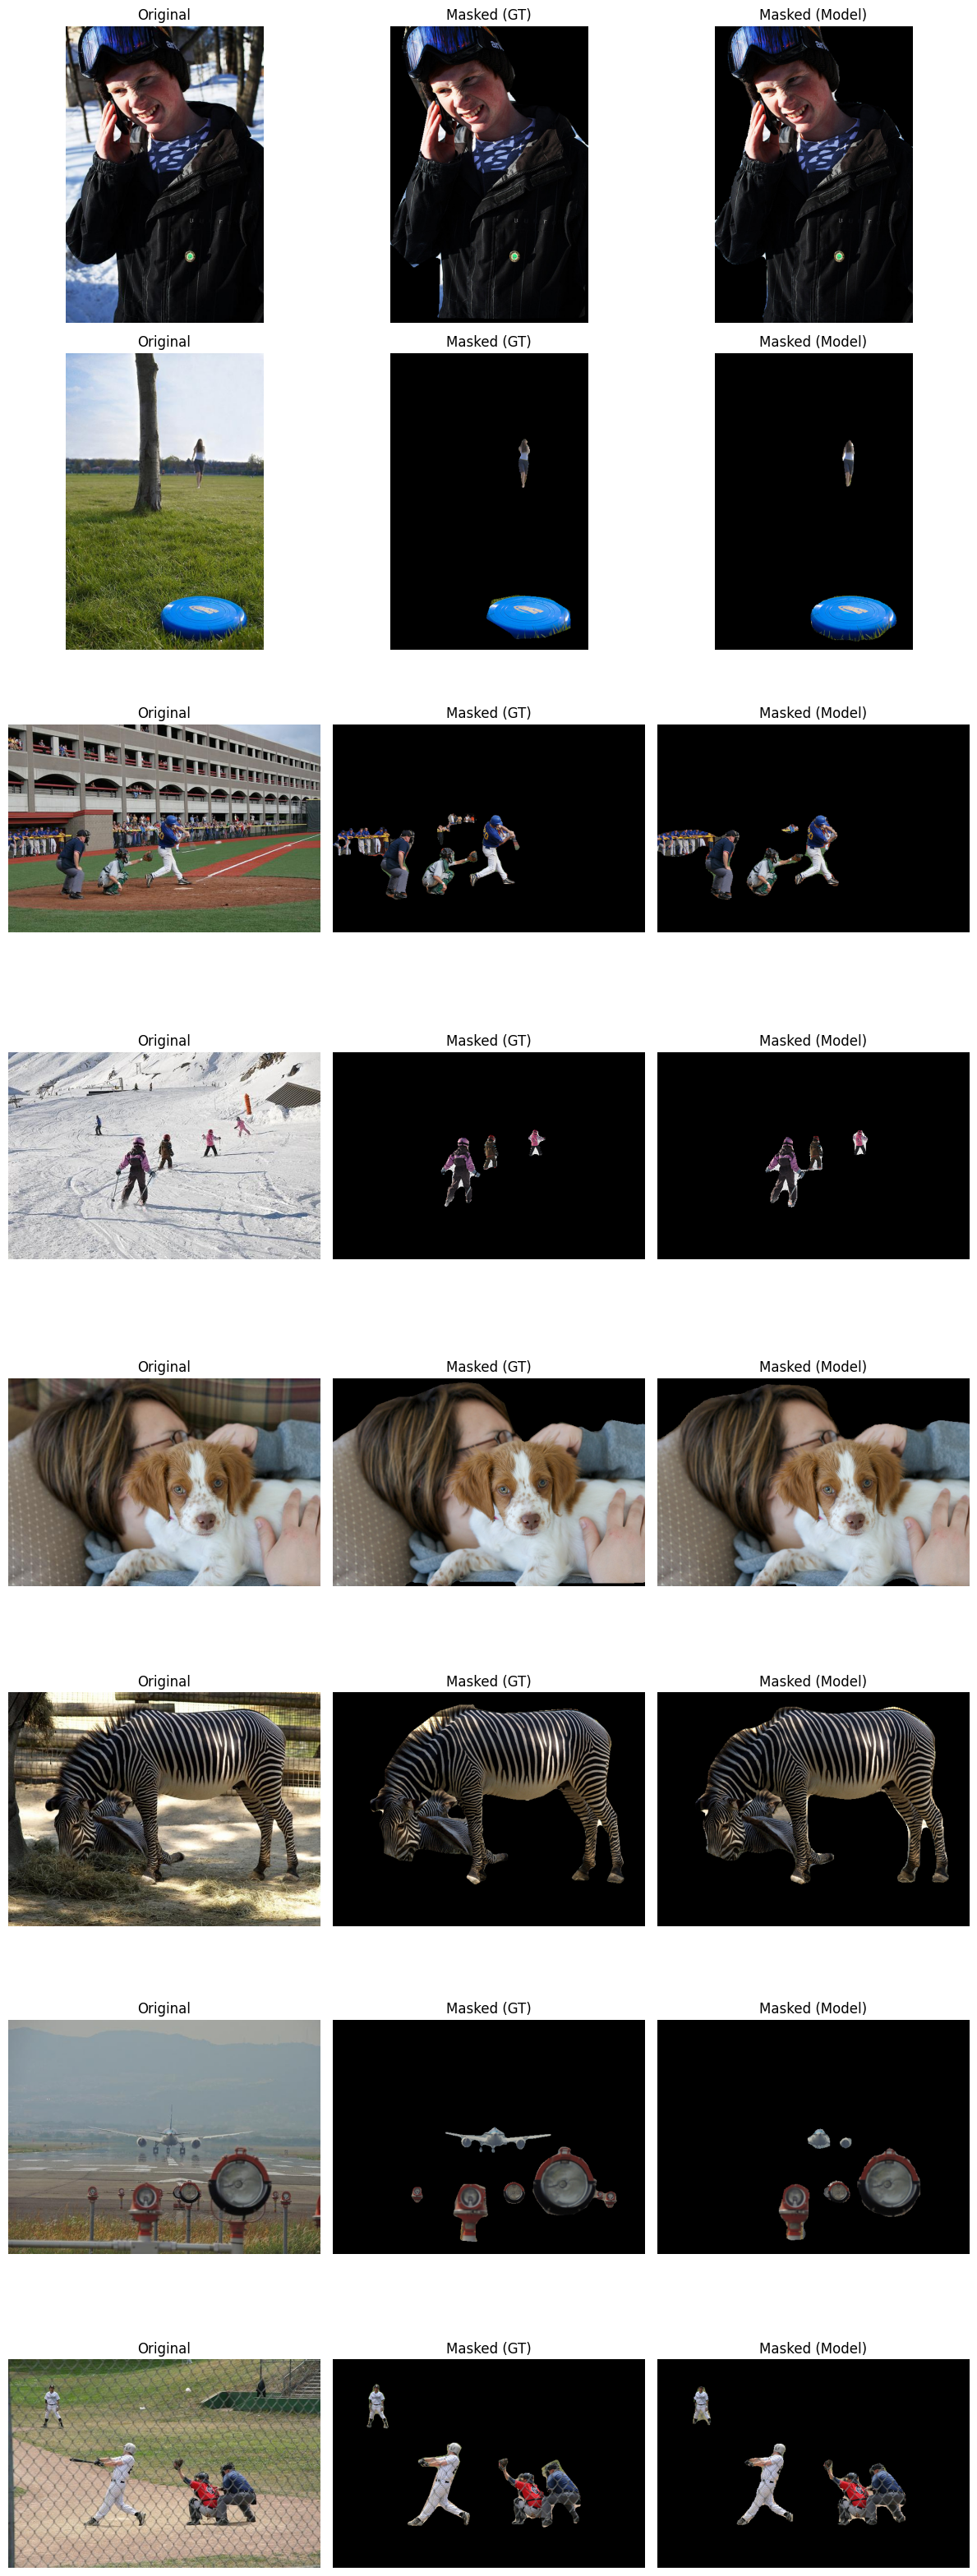

In [13]:
import os, random, time
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn.functional as F
import torchvision.models.segmentation as segmentation_models
CONFIG = {
    "model_ckpt": "/kaggle/working/best_seg_model.pth",
    "images_dir": "/kaggle/input/coco-2017-dataset/coco2017/val2017",
    "masks_dir": "/kaggle/working/val2017_masks",
    "out_dir": "/kaggle/working/masked_outputs",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "img_size": (512, 512),  
    "tta_flip": True,         
    "fg_thresh": 0.5,       
    "min_area": 300,          
    "keep_largest": False,    
    "preview_n": 8,
    "preview_mode": "fixed_seed", 
    "preview_list": [],          
    "seed": 123
}
images_dir = Path(CONFIG["images_dir"])
masks_dir = Path(CONFIG["masks_dir"])
out_dir = Path(CONFIG["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)
def list_images_with_masks(images_dir, masks_dir, mask_suffix="_mask.png"):
    imgs = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in ('.jpg','.jpeg','.png')])
    paired = []
    for p in imgs:
        mask_path = masks_dir / (p.stem + mask_suffix)
        if mask_path.exists():
            paired.append((p, mask_path))
    return paired

pairs = list_images_with_masks(images_dir, masks_dir)
print(f"Found {len(pairs)} Images")
if len(pairs) == 0:
    raise SystemExit("No image-mask pairs found. Check CONFIG paths and mask file naming (<stem>_mask.png).")

def get_model_and_load(name="deeplabv3_resnet50", checkpoint_path=None, num_classes=2, device='cpu'):
    if name == "deeplabv3_resnet50":
        model = segmentation_models.deeplabv3_resnet50(pretrained=False, progress=True, num_classes=num_classes)
    elif name == "fcn_resnet50":
        model = segmentation_models.fcn_resnet50(pretrained=False, progress=True, num_classes=num_classes)
    else:
        raise ValueError("Unknown model name")
    if checkpoint_path is not None and Path(checkpoint_path).exists():
        ck = torch.load(checkpoint_path, map_location='cpu')
        if isinstance(ck, dict):
            if "model_state" in ck:
                state = ck["model_state"]
            elif "state_dict" in ck:
                state = ck["state_dict"]
            elif "model_state_dict" in ck:
                state = ck["model_state_dict"]
            else:
                state = ck
        else:
            state = ck
        try:
            model.load_state_dict(state)
        except RuntimeError:
            new_state = {k.replace("module.", ""): v for k, v in state.items()}
            model.load_state_dict(new_state)
        print(f"Loaded Model from {checkpoint_path}")
    else:
        print(f"Warning: checkpoint not found at {checkpoint_path} — model will be randomly initialized.")
    model.to(device).eval()
    return model

device = torch.device(CONFIG["device"])
model = get_model_and_load(checkpoint_path=CONFIG["model_ckpt"], device=device)

def preprocess_image_cv2(img_rgb, size):
    h, w = size
    img = cv2.resize(img_rgb, (w, h), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img = (img - mean[None, None, :]) / std[None, None, :]
    img_chw = img.transpose(2, 0, 1)
    tensor = torch.from_numpy(img_chw).unsqueeze(0).float()
    return tensor

from scipy import ndimage as ndi
def postprocess_mask(prob_map, fg_thresh=0.5, min_area=300, keep_largest=False):
    mask = (prob_map >= fg_thresh).astype(np.uint8)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11,11))
    kernel_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    comps = []
    for lab in range(1, num_labels):
        area = stats[lab, cv2.CC_STAT_AREA]
        if area >= min_area:
            comps.append((lab, area))
            out[labels == lab] = 1
    if keep_largest and len(comps) > 0:
        comps.sort(key=lambda x: x[1], reverse=True)
        largest_lab = comps[0][0]
        out = (labels == largest_lab).astype(np.uint8)
    out = ndi.binary_fill_holes(out).astype(np.uint8)
    out = cv2.morphologyEx(out.astype(np.uint8), cv2.MORPH_OPEN, kernel_open)
    return (out * 255).astype(np.uint8)

def predict_prob_map(img_rgb, model, device, size, tta_flip=True):
    inp = preprocess_image_cv2(img_rgb, size).to(device)
    with torch.no_grad():
        logits = model(inp)['out']
        prob = F.softmax(logits, dim=1).cpu().numpy()[0,1,:,:] 
    probs = [prob]
    if tta_flip:
        img_f = img_rgb[:, ::-1, :].copy()
        inp_f = preprocess_image_cv2(img_f, size).to(device)
        with torch.no_grad():
            logits_f = model(inp_f)['out']
            prob_f = F.softmax(logits_f, dim=1).cpu().numpy()[0,1,:,:]
        prob_f = prob_f[:, ::-1]
        probs.append(prob_f)
    avg_prob = np.mean(np.stack(probs, axis=0), axis=0)
    return avg_prob.astype(np.float32)
for img_path, gt_mask_path in tqdm(pairs, desc="Processing mask pairs"):
    try:
        orig = np.array(Image.open(img_path).convert("RGB"))
    except Exception as e:
        print("skip", img_path, "read error:", e)
        continue
    prob_map_model_size = predict_prob_map(orig, model, device, CONFIG["img_size"], tta_flip=CONFIG["tta_flip"])
    pred_mask_model_size = postprocess_mask(prob_map_model_size,
                                            fg_thresh=CONFIG["fg_thresh"],
                                            min_area=CONFIG["min_area"],
                                            keep_largest=CONFIG["keep_largest"]) 

    orig_h, orig_w = orig.shape[:2]
    pred_mask_orig_size = cv2.resize(pred_mask_model_size, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)  
    pred_bin_orig = (pred_mask_orig_size > 127).astype(np.uint8)
    masked_by_model = orig.copy()
    masked_by_model[pred_bin_orig == 0] = 0 

    gt_mask_full = np.array(Image.open(gt_mask_path).convert("L"))
    if gt_mask_full.shape != (orig_h, orig_w):
        gt_mask_resized = cv2.resize(gt_mask_full, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    else:
        gt_mask_resized = gt_mask_full
    gt_bin_orig = (gt_mask_resized > 127).astype(np.uint8)
    masked_by_gt = orig.copy()
    masked_by_gt[gt_bin_orig == 0] = 0
    stem = img_path.stem
    Image.fromarray(orig).save(out_dir / (stem + "_orig.jpg"))
    Image.fromarray(masked_by_gt).save(out_dir / (stem + "_gt_masked.png"))
    Image.fromarray(masked_by_model).save(out_dir / (stem + "_model_masked.png"))
    Image.fromarray(pred_mask_orig_size).save(out_dir / (stem + "_pred_mask.png"))
print(f"Saved outputs to: {out_dir}")

def pick_preview(pairs, mode="fixed_seed", n=13, seed=CONFIG["seed"], file_list=None):
    all_stems = [p[0].stem for p in pairs]
    if mode == "random":
        return random.sample(all_stems, min(n, len(all_stems)))
    if mode == "fixed_seed":
        rng = random.Random(seed)
        return rng.sample(all_stems, min(n, len(all_stems)))
    if mode == "first_n":
        return all_stems[:min(n, len(all_stems))]
    if mode == "list":
        picks = []
        for name in (file_list or []):
            stem = Path(name).stem
            if stem in all_stems:
                picks.append(stem)
            else:
                print("Warning: requested preview file not found:", name)
        return picks[:n]
    return all_stems[:min(n, len(all_stems))]

preview_stems = pick_preview(pairs, mode=CONFIG["preview_mode"], n=CONFIG["preview_n"], seed=CONFIG["seed"], file_list=CONFIG["preview_list"])

n_show = len(preview_stems)
if n_show == 0:
    print("No preview files selected.")
else:
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
    if n_show == 1:
        axes = np.expand_dims(axes, 0)
    for i, stem in enumerate(preview_stems):
        orig_img = np.array(Image.open(out_dir / (stem + "_orig.jpg")).convert("RGB"))
        gt_img   = np.array(Image.open(out_dir / (stem + "_gt_masked.png")).convert("RGB"))
        model_img= np.array(Image.open(out_dir / (stem + "_model_masked.png")).convert("RGB"))
        axes[i, 0].imshow(orig_img); axes[i,0].axis("off"); axes[i,0].set_title("Original")
        axes[i, 1].imshow(gt_img);   axes[i,1].axis("off"); axes[i,1].set_title("Masked (GT)")
        axes[i, 2].imshow(model_img);axes[i,2].axis("off"); axes[i,2].set_title("Masked (Model)")
    plt.tight_layout()
    plt.show()